# Gradient Descent for Traffic Forecasting

In this notebook, we will attempt to use machine learning optimisation algorithms to predict latency (response time) from request rates.

First, we compare the results of gradient descent and the normal equation. We then create two linear models:
1. **Model 1**: Predict **CPU** from time — forecast CPU in the near future. This model has **one feature**, CPU.
2. **Model 2**: Predict **latency** from CPU and network (RX/TX) — estimate latency given the forecasted CPU. This model has **three features**, CPU, Network RX, and Network TX.

By using this notebook, we hope to help you develop some reasoning about how machine learning prediction works with multiple features and how optimisation algorithms work to reduce the prediction error (Mean-Squared Error).

We use the Microservices Bottleneck Detection dataset, available on Kaggle ([gagansomashekar/microservices-bottleneck-detection-dataset](https://www.kaggle.com/datasets/gagansomashekar/microservices-bottleneck-detection-dataset)).

---
## Introduction to Gradient Descent and Linear Regression

As we learned in our [previous notebook](https://github.com/OpeOnikute/promml/blob/main/notebooks/linear_predict.ipynb), **Linear regression** fits a linear function to data.


by minimizing the mean squared error (MSE). Given features $X$ and target $y$:

$$\hat{y} = X\theta \quad \text{, minimize} \quad \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$$

- **Closed-form (normal equation)**: $\theta = (X^T X)^{-1} X^T y$ — one-step solution (with small ridge for stability).
- **Gradient descent**: start with $\theta = 0$, then repeatedly update $\theta \leftarrow \theta - \alpha \cdot \frac{2}{n} X^T(X\theta - y)$. The step size $\alpha$ is the **learning rate**; we run for a fixed number of **epochs** (or until the gradient is tiny).

Both methods minimize the same MSE; gradient descent converges to the same solution if we tune learning rate and epochs. If GD predictions look wrong, it's usually because they haven't converged yet.

---
## 2. The Two Models We Will Implement

| Model | Features ($X$) | Target ($y$) | Purpose |
|-------|----------------|--------------|--------|
| **Model 1** | Intercept, time (window index) | CPU | Forecast CPU in 30 minutes using a simple linear trend. |
| **Model 2** | Intercept, CPU, net RX, net TX | Latency (ms) | Estimate latency from current (or forecasted) CPU and network. Fit only on **baseline** (pre-saturation) data. |

**End-to-end**: Use Model 1 to forecast CPU (and optionally net RX/TX) 30 minutes ahead, then plug those into Model 2 to estimate latency at that time.

---
## 3. Dataset

We use the **processed** microservices dataset: one CSV per (service, scenario, graph). Each row is a request; metrics (CPU, memory, network RX/TX) are constant per **window_id**. We aggregate by window to get one row per time window with mean latency and the shared metrics. Scenarios prefixed with `<c-latency>-` in the `scenarios/` folder are chosen for clear latency saturation. Expect: CPU and network rising over time, with latency staying low then jumping when the system saturates.

### Setup: install dependencies

Run the cell below **once** if you get `ModuleNotFoundError: No module named 'numpy'` (or pandas/matplotlib). It installs packages into whichever Python the notebook kernel is using. Then re-run the next cell. Prefer using a venv: create one with `python -m venv .venv`, install with `pip install -r requirements.txt`, then choose that interpreter as the kernel.

In [1]:
# Install dependencies into the current Jupyter kernel (run this cell once if you get ModuleNotFoundError).
# If you use a venv, select it as the kernel: Kernel → Change Kernel → Python (./.venv/...)
%pip install numpy pandas matplotlib ipywidgets --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Set up the notebook: choose one example from the dataset
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "linear_regression_saturation.py").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helpers from our scripts
from visualise_processed_dataset import *
from linear_regression_saturation import *

# Resolves paths, picks first <c-latency> scenario, loads aggregated window data and metric columns.
# Pass data_dir=Path("...") to override the processed dataset location.
win, metric_cols, CHOSEN_STEM = setup_notebook()
print(f"Chosen scenario: {CHOSEN_STEM}")
print(f"Windows: {len(win)}")

Chosen scenario: cpu_aug9_25min_400_8_graph_1
Windows: 290


---
## 4. Plot Metrics (CPU, Network, Latency) for the Chosen Scenario

Time series of CPU, memory, network RX/TX, and latency per window — the same view as `visualise_processed_dataset.py`.

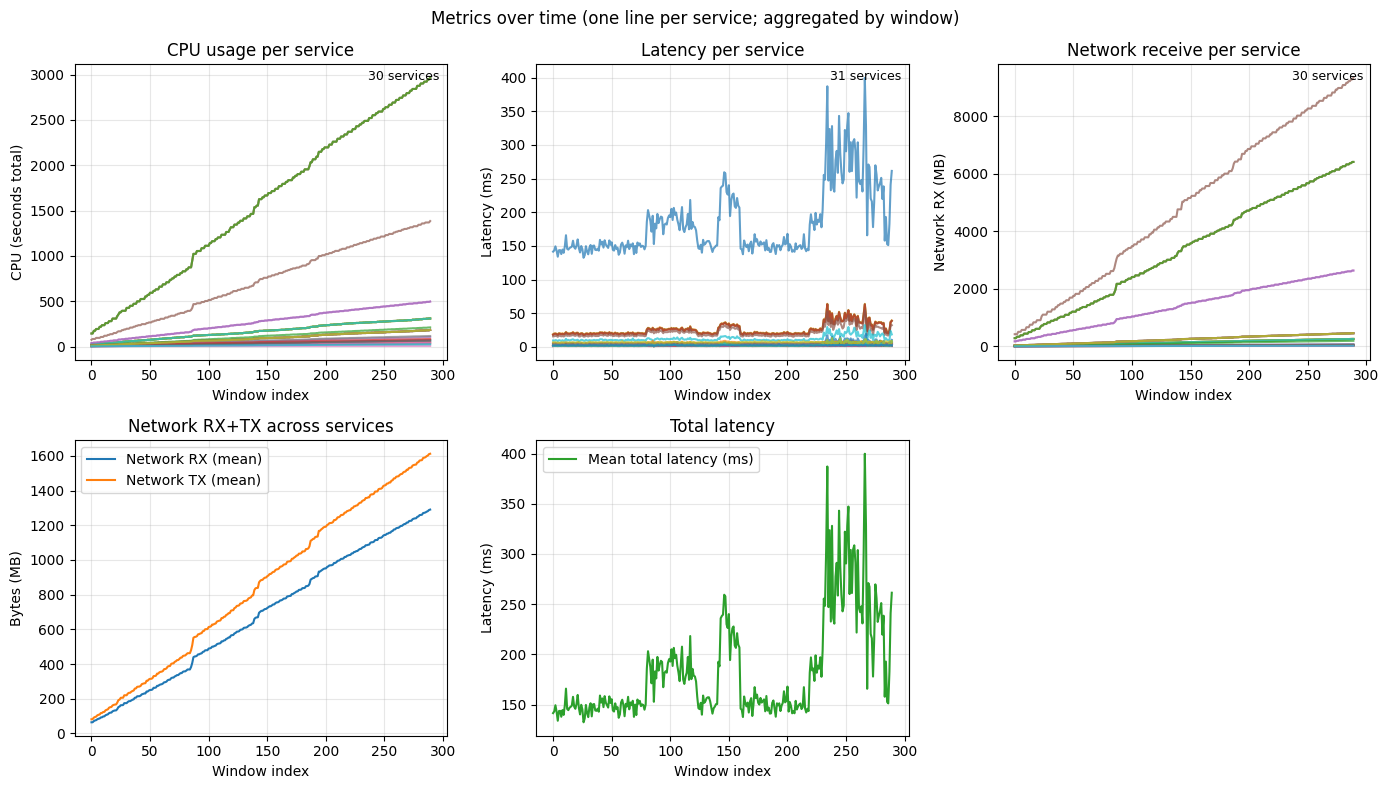

In [4]:
plot_time_series(win, metric_cols, show=True)

---
## 5. Model 1: Predicting CPU from Time (Closed-Form and Gradient Descent)

We predict **CPU** using only time (window index): $X = [1, t]$, $y = \text{CPU}$. Both closed-form and gradient descent minimize the same MSE; gradient descent needs a suitable learning rate and enough epochs to converge.

In [ ]:
def fit_closed_form(X, y):
    """Normal equation: theta = (X'X)^{-1} X'y. Ridge (lam=1e-6) for stability."""
    lam = 1e-6
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def fit_gradient_descent(X, y, lr=0.1, epochs=50_000, tol=1e-8):
    """Gradient descent: theta := theta - lr * (2/n) * X'(X theta - y). Stops when gradient norm < tol."""
    n = X.shape[0]
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        pred = X @ theta
        grad = (2 / n) * (X.T @ (pred - y))
        if np.linalg.norm(grad) < tol:
            break
        theta -= lr * grad
    return theta

def plot_cpu_model1(t, y_actual, pred_cf, pred_gd, stem):
    """Plot actual CPU vs closed-form and gradient-descent predictions."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, y_actual, "k.", alpha=0.6, label="Actual CPU")
    ax.plot(t, pred_cf, "C0-", alpha=0.9, label="Predicted (closed-form)")
    ax.plot(t, pred_gd, "C1--", alpha=0.9, label="Predicted (gradient descent)")
    ax.set_xlabel("Window index (time)")
    ax.set_ylabel("CPU")
    ax.set_title(f"Model 1: CPU vs time — {stem}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

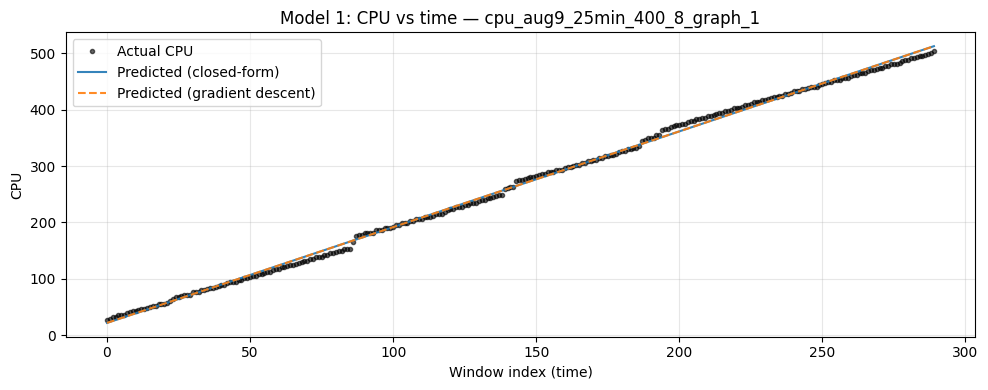

In [4]:
# X = [1, t], y = CPU
cpu_mean = win[metric_cols["cpu"]].mean(axis=1).values
n_windows = len(cpu_mean)
t = np.arange(n_windows, dtype=float)
X_cpu = np.column_stack([np.ones(n_windows), t])
y_cpu = cpu_mean

# Closed-form: theta = (X'X)^{-1} X'y
theta_cf = fit_closed_form(X_cpu, y_cpu)
pred_cf = X_cpu @ theta_cf

# Gradient descent: iterative (scale features for stability)
X_gd = X_cpu.copy()
X_gd[:, 1] = (X_gd[:, 1] - X_gd[:, 1].mean()) / (X_gd[:, 1].std() + 1e-8)
y_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
theta_gd = fit_gradient_descent(X_gd, y_gd, lr=0.5, epochs=5000)
pred_gd = (X_gd @ theta_gd) * y_cpu.std() + y_cpu.mean()

plot_cpu_model1(t, y_cpu, pred_cf, pred_gd, CHOSEN_STEM)

### 5.1 Interactive: Tune Learning Rate and Epochs

Use the sliders to see how gradient descent fails to converge when the learning rate is too small or epochs too few, and converges when they are adequate.

In [5]:
from ipywidgets import interact, FloatLogSlider, IntSlider

def run_gd_cpu(lr=0.1, epochs=5000):
    X_gd = X_cpu.copy()
    X_gd[:, 1] = (X_gd[:, 1] - X_gd[:, 1].mean()) / (X_gd[:, 1].std() + 1e-8)
    y_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
    theta = fit_gradient_descent(X_gd, y_gd, lr=lr, epochs=epochs)
    pred = (X_gd @ theta) * y_cpu.std() + y_cpu.mean()
    mse = np.mean((y_cpu - pred) ** 2)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, y_cpu, "k.", alpha=0.6, label="Actual CPU")
    ax.plot(t, pred_cf, "C0-", alpha=0.8, label="Closed-form")
    ax.plot(t, pred, "C1--", alpha=0.9, label=f"GD (lr={lr}, epochs={epochs}), MSE={mse:.4f}")
    ax.set_xlabel("Window index")
    ax.set_ylabel("CPU")
    ax.set_title("Model 1: effect of learning rate and epochs")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    run_gd_cpu,
    lr=FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.2, description="Learning rate"),
    epochs=IntSlider(value=5000, min=100, max=50000, step=500, description="Epochs"),
)

interactive(children=(FloatLogSlider(value=0.1, description='Learning rate', max=0.0, min=-3.0, step=0.2), Int…

<function __main__.run_gd_cpu(lr=0.1, epochs=5000)>

---
## 6. Traffic Forecasting Problem

We want to estimate **how future demand will impact latency**: if load (and thus CPU and network) keeps trending up, what latency can we expect in 30 minutes? We do this in two steps:
1. **Forecast CPU (and optionally net RX/TX)** in 30 minutes using Model 1–style linear extrapolation.
2. **Plug those values into Model 2** (latency from CPU and network) to estimate latency at that time.

Model 2 is only reliable in the **baseline** (pre-saturation) regime; once the system saturates, latency is no longer linear in CPU/network.

---
## 7. Model 2: Predicting Latency from CPU and Network

Features: intercept, CPU, network RX (MB), network TX (MB). Target: latency (ms). We fit on **baseline only** (windows before the latency spike) so the linear assumption holds.

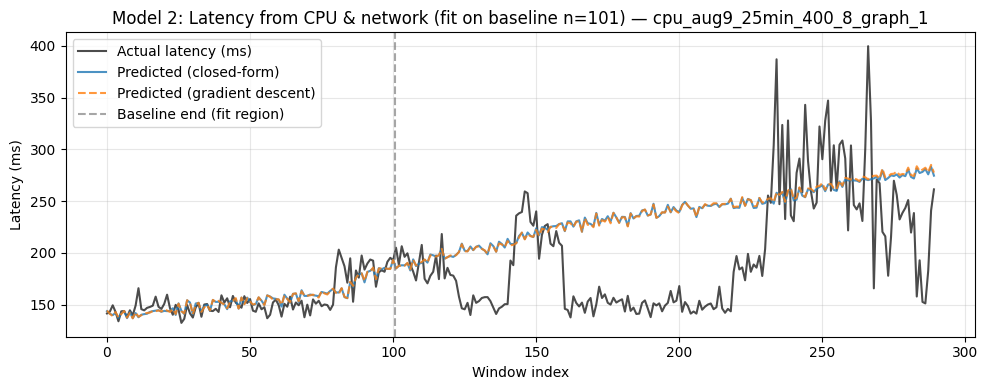

In [6]:
theta_cf_lat, theta_gd_lat, baseline_end, net_rx, net_tx, y_lat, X_fit, y_mean_lat, y_std_lat = run_model2_latency(
    win, metric_cols, cpu_mean, n_windows, CHOSEN_STEM
)

---
## 8. Why Only the Baseline?

Once saturation hits, latency **stops being linear** in CPU and network: it flattens or jumps. Fitting a single linear model over the full timeline would be pulled by those high-latency points and would mispredict both the normal and saturated regions. By fitting **only on baseline** (pre-spike) data, we get a model that describes "latency as a function of load" in the regime where that relationship is roughly linear. We can then use it to estimate latency for **forecasted** CPU/network (e.g. 30 minutes ahead) as long as we stay in a range the model was trained on.

---
## 9. End-to-End: Forecast CPU in 30 Minutes, Then Latency

1. Use the **Model 1** trend (CPU vs time) on the baseline segment to extrapolate CPU (and optionally net RX/TX) to a time 30 minutes after the end of the baseline.
2. Build the feature vector for that future point and pass it to **Model 2** to get predicted latency.

Forecast at t = 449 (~30 min after baseline end):
  CPU = 746.6775,  net_rx = 1895.88 MB,  net_tx = 2371.37 MB
  Predicted latency (closed-form) = 318.4 ms
  Predicted latency (gradient descent) = 318.3 ms


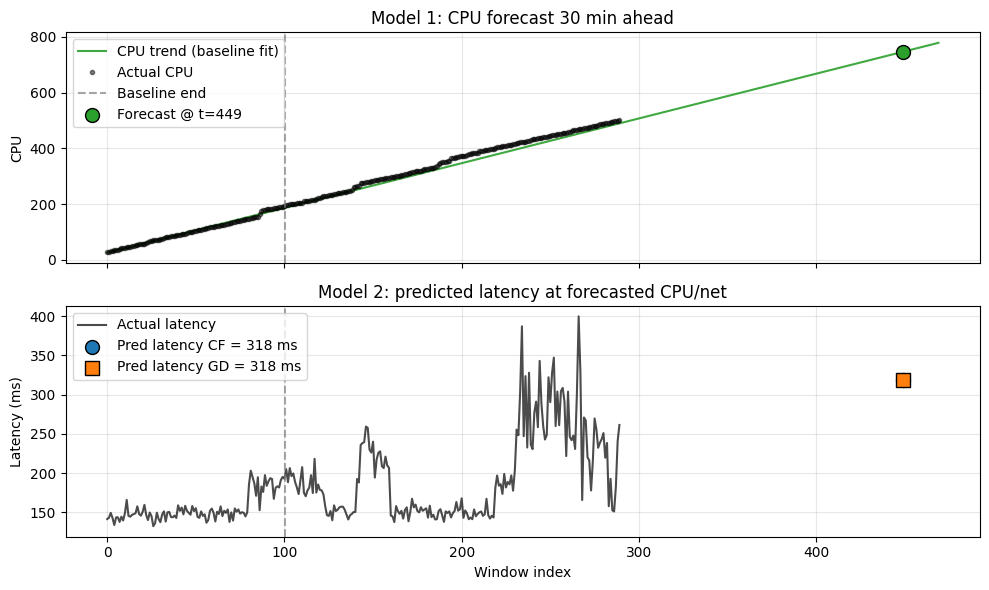

In [7]:
run_forecast_30min(
    CHOSEN_STEM,
    n_windows,
    baseline_end,
    cpu_mean,
    net_rx,
    net_tx,
    y_lat,
    theta_cf_lat,
    theta_gd_lat,
    X_fit,
    y_mean_lat,
    y_std_lat,
    minutes_ahead=30,
)